In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("Housing.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
print("Dataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB

Column Names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefare

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [4]:
# Convert categorical columns into numerical values

df_processed = pd.get_dummies(
    df,
    columns=[
        'mainroad',
        'guestroom',
        'basement',
        'hotwaterheating',
        'airconditioning',
        'prefarea',
        'furnishingstatus'
    ],
    drop_first=True,
    dtype=int
)

print("Preprocessing completed successfully!")
print("New shape:", df_processed.shape)

df_processed.head()

Preprocessing completed successfully!
New shape: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [5]:
# Select features and target

X = df_processed.drop('price', axis=1)
y = df_processed['price']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (545, 13)
Target (y) shape: (545,)


In [6]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 13)
Testing data: (109, 13)


In [7]:
# Create Linear Regression model

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [8]:
# Make predictions on test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[5164653.90033967 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725956 3532275.09556558 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782]


In [9]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

Model Evaluation:
MAE: 970043.403920164
MSE: 1754318687330.6643
R² Score: 0.6529242642153184


In [10]:
# Compare actual and predicted prices

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


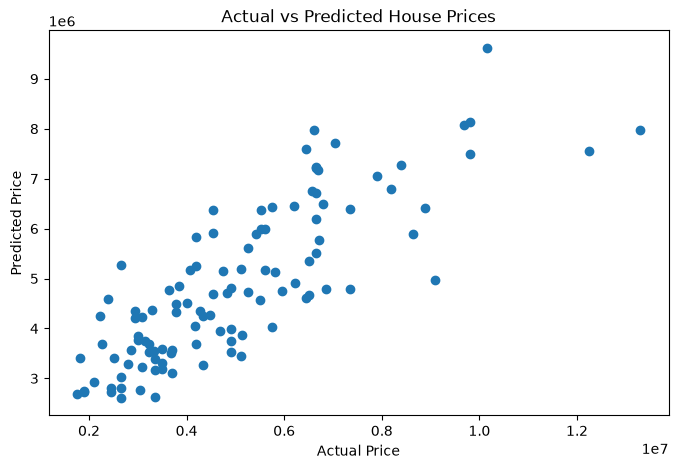

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [12]:
# Display model coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05
1,bedrooms,7.677870e+04


In [17]:
print("Intercept:", model.intercept_)

Intercept: 260032.35760741495


## Coefficient Interpretation

The coefficient of each feature shows how the predicted house price changes when that feature changes, while keeping other features constant.

A positive coefficient indicates a positive relationship with house price.

A negative coefficient indicates a negative relationship with house price.

For example, if the coefficient of `area` is positive, increasing the area is associated with an increase in the predicted house price, assuming other features remain constant.

In [16]:
# Simple Linear Regression using area only

X_simple = df_processed[['area']]
y_simple = df_processed['price']

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,
    y_simple,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train_simple, y_train_simple)

y_pred_simple = simple_model.predict(X_test_simple)

print("Simple Linear Regression completed!")

Simple Linear Regression completed!


In [18]:
# Evaluate Simple Linear Regression

mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
r2_simple = r2_score(y_test_simple, y_pred_simple)

print("Simple Linear Regression:")
print("MAE:", mae_simple)
print("MSE:", mse_simple)
print("R² Score:", r2_simple)

Simple Linear Regression:
MAE: 1474748.1337969352
MSE: 3675286604768.185
R² Score: 0.27287851871974644


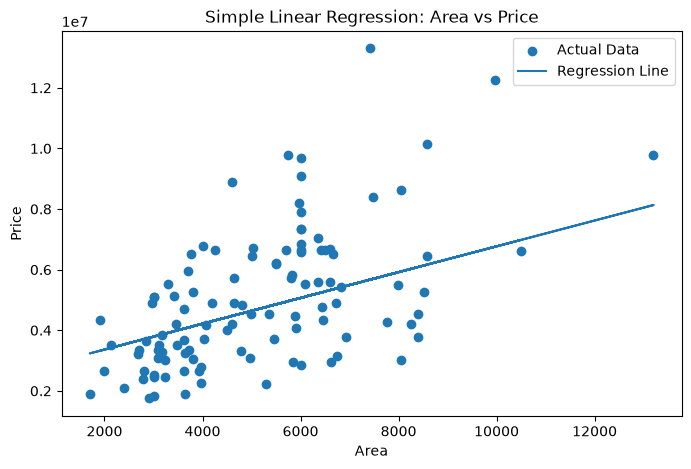

In [19]:
# Plot regression line

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_simple['area'],
    y_test_simple,
    label='Actual Data'
)

plt.plot(
    X_test_simple['area'],
    y_pred_simple,
    label='Regression Line'
)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Simple Linear Regression: Area vs Price")
plt.legend()

plt.show()

In [20]:
print("Simple Regression Coefficient:", simple_model.coef_[0])
print("Simple Regression Intercept:", simple_model.intercept_)

Simple Regression Coefficient: 425.72984193878284
Simple Regression Intercept: 2512254.2639593435


In [21]:
comparison_results = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multiple Linear Regression'
    ],
    'MAE': [
        mae_simple,
        mae
    ],
    'MSE': [
        mse_simple,
        mse
    ],
    'R2 Score': [
        r2_simple,
        r2
    ]
})

comparison_results

,Model,MAE,MSE,R2 Score
0,Simple Linear Regression,1.474748e+06,3.675287e+12,0.272879
1,Multiple Linear Regression,9.700434e+05,1.754319e+12,0.652924


## Observations

1. The dataset contains 545 house records and 13 original features.
2. The target variable is `price`.
3. Categorical variables were converted into numerical values using one-hot encoding.
4. The dataset did not contain missing values.
5. The data was divided into 80% training and 20% testing data.
6. Simple Linear Regression was performed using `area` as the predictor.
7. Multiple Linear Regression was performed using multiple house-related features.
8. MAE, MSE, and R² were used to evaluate model performance.
9. The regression line shows the relationship between house area and price.
10. Model coefficients help understand how individual features influence predicted house price.

## Conclusion

In this task, Simple and Multiple Linear Regression were implemented using Python and Scikit-learn.

The dataset was loaded and preprocessed by converting categorical variables into numerical values. The data was divided into training and testing sets.

The Linear Regression model was trained and evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score.

A regression line was plotted for Simple Linear Regression, and model coefficients were analyzed to understand the relationship between features and house prices.

This task provided practical understanding of regression modeling, model evaluation, visualization, and coefficient interpretation.